In [6]:
import sys
!{sys.executable} -m pip install spacy scikit-learn

  Using cached spacy_legacy-3.0.12-py2.py3-none-any.whl.metadata (2.8 kB)
  Using cached spacy_loggers-1.0.5-py3-none-any.whl.metadata (23 kB)
  Using cached wasabi-1.1.3-py3-none-any.whl.metadata (28 kB)
  Using cached catalogue-2.0.10-py3-none-any.whl.metadata (14 kB)
  Using cached weasel-1.0.0-py3-none-any.whl.metadata (4.6 kB)
  Using cached confection-1.3.3-py3-none-any.whl.metadata (19 kB)
  Using cached shellingham-1.5.4-py2.py3-none-any.whl.metadata (3.5 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
  Using cached cloudpathlib-0.23.0-py3-none-any.whl.metadata (16 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached anyio-4.13.0-py3-none-any.whl.metadata (4.5 kB)
  Using cached httpcore-1.0.9-py3-none-any.whl.metadata (21 kB)
  Using cached h11-0.16.0-py3-none-any.whl.metadata (8.3 kB)
  Using cached markdown_it_py-4.0.0-py3-none-any.whl.metadata (7.3 kB)
  Usin


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
import sys
!{sys.executable} -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB ? eta -:--:--
     --- ------------------------------------ 1.0/12.8 MB 4.2 MB/s eta 0:00:03
     ------ --------------------------------- 2.1/12.8 MB 4.3 MB/s eta 0:00:03
     --------- ------------------------------ 3.1/12.8 MB 4.5 MB/s eta 0:00:03
     --------------- ------------------------ 5.0/12.8 MB 5.6 MB/s eta 0:00:02
     --------------------- ------------------ 6.8/12.8 MB 6.2 MB/s eta 0:00:01
     ------------------------ --------------- 7.9/12.8 MB 5.9 MB/s eta 0:00:01
     ------------------------------- -------- 10.2/12.8 MB 6.6 MB/s eta 0:00:01
     ---------------------------------------  12.6/12.8 MB 7.2 MB/s eta 0:00:01
     ---------------------------------------- 12.8/12.8 MB 6.9 MB/s  0:00:02
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import spacy
import json
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [9]:
nlp = spacy.load("en_core_web_sm")

In [10]:
ALIENS = ["Heatblast", "XLR8", "Four Arms", "Diamondhead"]

In [11]:
missions = [
    "Heatblast was spotted in New York attacking Forever Knights base on 12th June. Threat level is high.",
    "XLR8 detected in Tokyo during a chase near Plumber HQ. Threat level is medium.",
    "Four Arms appeared in Mumbai causing destruction on 5th May. Threat level is high.",
    "Diamondhead seen in London protecting civilians. Threat level is low."
]

In [12]:
def detect_threat(text):
    text = text.lower()
    if "high" in text:
        return "High"
    elif "medium" in text:
        return "Medium"
    elif "low" in text:
        return "Low"
    return "Unknown"

In [13]:
def extract_info(report):
    doc = nlp(report)

    data = {
        "Alien": None,
        "Location": None,
        "Organization": None,
        "Date": None,
        "Threat": detect_threat(report),
        "Text": report
    }

    # Detect Alien (custom entity)
    for alien in ALIENS:
        if alien in report:
            data["Alien"] = alien

    # Extract using spaCy
    for ent in doc.ents:
        if ent.label_ == "GPE":
            data["Location"] = ent.text
        elif ent.label_ == "ORG":
            data["Organization"] = ent.text
        elif ent.label_ == "DATE":
            data["Date"] = ent.text

    return data

In [14]:
structured_data = []

for m in missions:
    result = extract_info(m)
    structured_data.append(result)

structured_data

[{'Alien': 'Heatblast',
  'Location': 'New York',
  'Organization': None,
  'Date': '12th June',
  'Threat': 'High',
  'Text': 'Heatblast was spotted in New York attacking Forever Knights base on 12th June. Threat level is high.'},
 {'Alien': 'XLR8',
  'Location': 'Plumber',
  'Organization': 'XLR8',
  'Date': None,
  'Threat': 'Medium',
  'Text': 'XLR8 detected in Tokyo during a chase near Plumber HQ. Threat level is medium.'},
 {'Alien': 'Four Arms',
  'Location': 'Mumbai',
  'Organization': None,
  'Date': None,
  'Threat': 'High',
  'Text': 'Four Arms appeared in Mumbai causing destruction on 5th May. Threat level is high.'},
 {'Alien': 'Diamondhead',
  'Location': 'London',
  'Organization': None,
  'Date': None,
  'Threat': 'Low',
  'Text': 'Diamondhead seen in London protecting civilians. Threat level is low.'}]

In [15]:
for i, data in enumerate(structured_data, 1):
    print(f"\n--- Mission {i} ---")
    for k, v in data.items():
        if k != "Text":
            print(f"{k}: {v}")


--- Mission 1 ---
Alien: Heatblast
Location: New York
Organization: None
Date: 12th June
Threat: High

--- Mission 2 ---
Alien: XLR8
Location: Plumber
Organization: XLR8
Date: None
Threat: Medium

--- Mission 3 ---
Alien: Four Arms
Location: Mumbai
Organization: None
Date: None
Threat: High

--- Mission 4 ---
Alien: Diamondhead
Location: London
Organization: None
Date: None
Threat: Low


In [16]:
with open("missions.json", "w") as f:
    json.dump(structured_data, f, indent=4)

print("✅ Missions saved!")

✅ Missions saved!


In [17]:
with open("missions.json", "r") as f:
    stored_missions = json.load(f)

stored_missions

[{'Alien': 'Heatblast',
  'Location': 'New York',
  'Organization': None,
  'Date': '12th June',
  'Threat': 'High',
  'Text': 'Heatblast was spotted in New York attacking Forever Knights base on 12th June. Threat level is high.'},
 {'Alien': 'XLR8',
  'Location': 'Plumber',
  'Organization': 'XLR8',
  'Date': None,
  'Threat': 'Medium',
  'Text': 'XLR8 detected in Tokyo during a chase near Plumber HQ. Threat level is medium.'},
 {'Alien': 'Four Arms',
  'Location': 'Mumbai',
  'Organization': None,
  'Date': None,
  'Threat': 'High',
  'Text': 'Four Arms appeared in Mumbai causing destruction on 5th May. Threat level is high.'},
 {'Alien': 'Diamondhead',
  'Location': 'London',
  'Organization': None,
  'Date': None,
  'Threat': 'Low',
  'Text': 'Diamondhead seen in London protecting civilians. Threat level is low.'}]

In [18]:
def search_missions(query, missions):
    texts = [m["Text"] for m in missions]

    vectorizer = TfidfVectorizer()
    tfidf_matrix = vectorizer.fit_transform(texts + [query])

    similarity = cosine_similarity(tfidf_matrix[-1], tfidf_matrix[:-1])

    ranked = similarity[0].argsort()[::-1]

    results = [missions[i] for i in ranked[:3]]
    return results

In [19]:
query = "high threat attack"
results = search_missions(query, stored_missions)

for r in results:
    print("\n🔍 Match:")
    print(r["Text"])


🔍 Match:
Four Arms appeared in Mumbai causing destruction on 5th May. Threat level is high.

🔍 Match:
Heatblast was spotted in New York attacking Forever Knights base on 12th June. Threat level is high.

🔍 Match:
Diamondhead seen in London protecting civilians. Threat level is low.


In [20]:
print("🤖 Ben 10 AI Chatbot (type 'exit' to stop)\n")

while True:
    user_input = input("You: ")

    if user_input.lower() == "exit":
        break

    if "search" in user_input.lower():
        results = search_missions(user_input, stored_missions)
        print("\n🔍 Results:")
        for r in results:
            print("-", r["Text"])
    else:
        data = extract_info(user_input)
        stored_missions.append(data)

        print("\n🧠 Extracted Info:")
        for k, v in data.items():
            if k != "Text":
                print(f"{k}: {v}")

    print("\n")

🤖 Ben 10 AI Chatbot (type 'exit' to stop)


🧠 Extracted Info:
Alien: Heatblast
Location: Delhi
Organization: None
Date: None
Threat: High




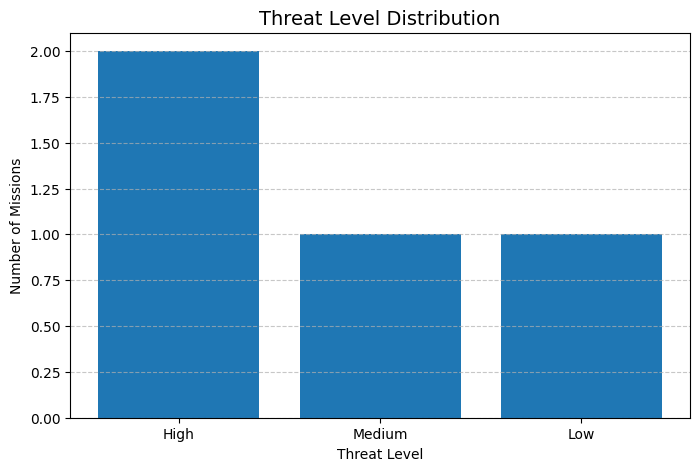

In [25]:
import matplotlib.pyplot as plt
from collections import Counter

# Extract threat levels
threats = [m["Threat"] for m in structured_data]

# Count frequencies
count = Counter(threats)

# Plot
plt.figure(figsize=(8,5))
plt.bar(count.keys(), count.values())

plt.title("Threat Level Distribution", fontsize=14)
plt.xlabel("Threat Level")
plt.ylabel("Number of Missions")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

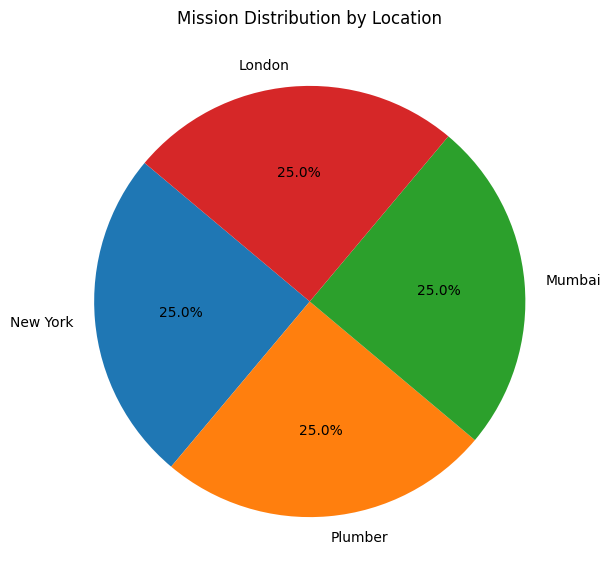

In [26]:
from collections import Counter
import matplotlib.pyplot as plt

locations = [m["Location"] for m in structured_data if m["Location"]]

count = Counter(locations)

plt.figure(figsize=(7,7))
plt.pie(count.values(), labels=count.keys(), autopct='%1.1f%%', startangle=140)

plt.title("Mission Distribution by Location")
plt.show()

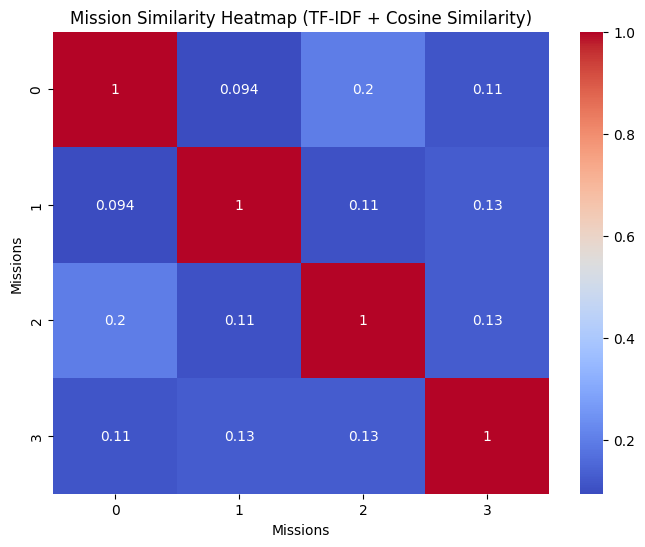

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

texts = [m["Text"] for m in structured_data]

vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(texts)

similarity_matrix = cosine_similarity(tfidf_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')

plt.title("Mission Similarity Heatmap (TF-IDF + Cosine Similarity)")
plt.xlabel("Missions")
plt.ylabel("Missions")

plt.show()